# Solar Radio Burst Data Demo

Run the cells below to generate example spectrograms from the synthetic burst generators and view them inline.

In [ ]:
#!pip install matplotlib
#!pip install scipy

In [3]:
from pathlib import Path
import sys

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "data_gen").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not find the repo root containing data_gen")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

from data_gen import (
    generate_no_burst,
    generate_type_1,
    generate_type_2,
    generate_type_3,
    generate_type_4,
    generate_type_5,
    generate_type_6,
    generate_type_7,
    generate_type_8,
    generate_rfi,
)

print(f"Using repo root: {repo_root}")

Using repo root: /Users/prisha/Library/CloudStorage/OneDrive-Personal/Documents/GitHub/solar-radio-classifier


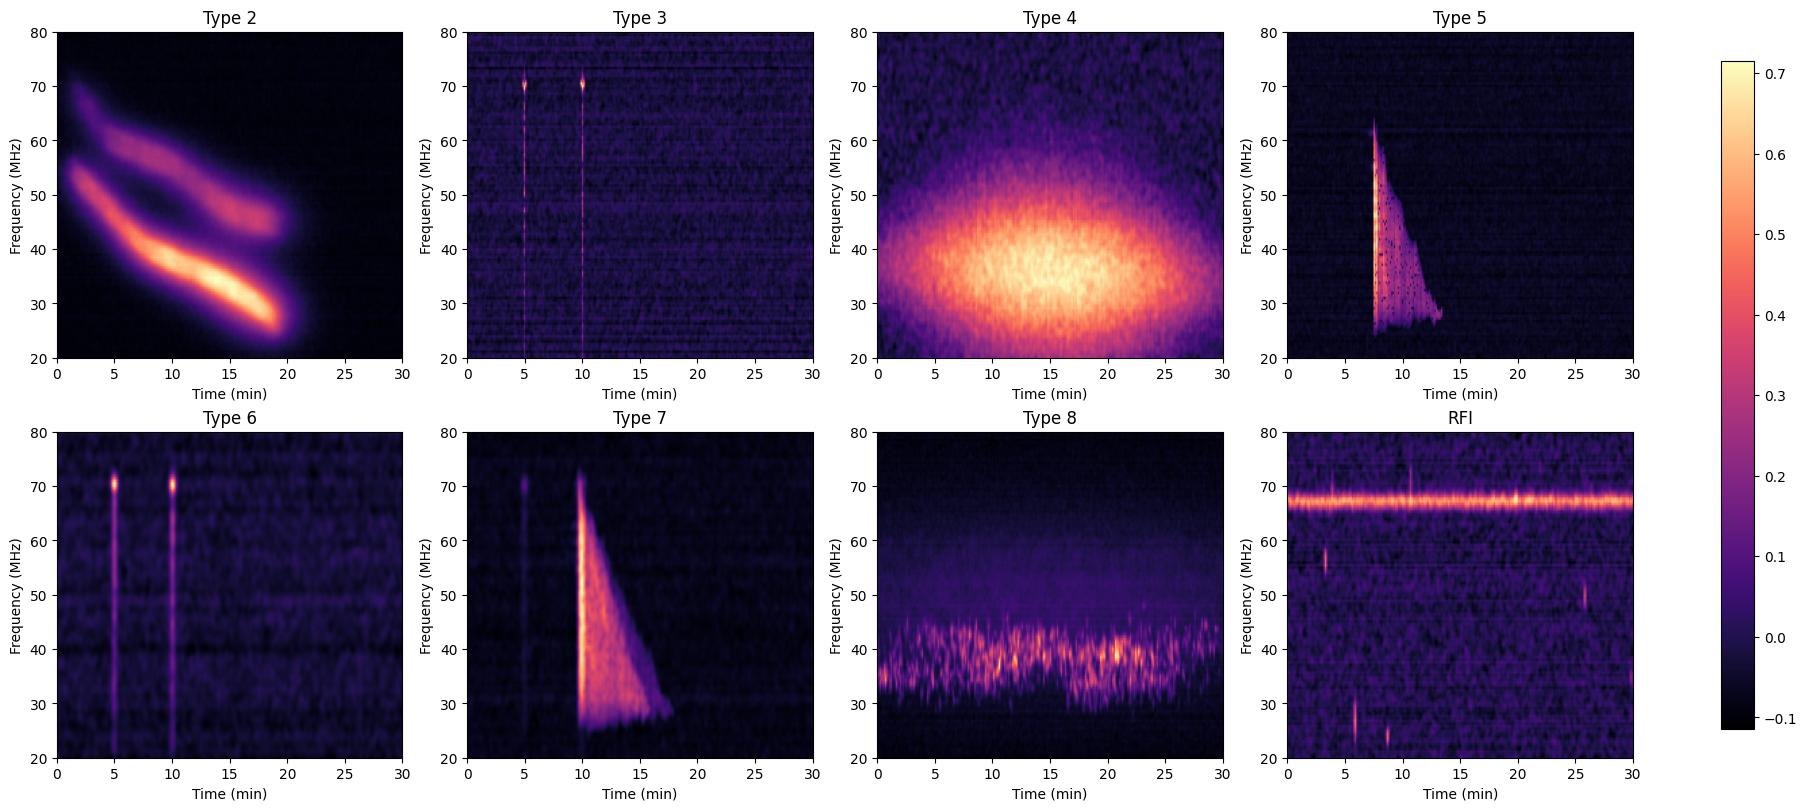

In [4]:
# Physical axis mapping: frequency in MHz, time in minutes
import numpy as np

# Choose physical ranges (adjustable)
f_min_mhz, f_max_mhz = 20.0, 80.0  # MHz
duration_min = 30.0               # total span in minutes
freq_bins = 128
time_bins = 256

# Axis vectors for labeling
freq_axis = np.linspace(f_min_mhz, f_max_mhz, freq_bins)
time_axis = np.linspace(0.0, duration_min, time_bins)

generators = [
    ("Type 2", generate_type_2),
    ("Type 3", generate_type_3),
    ("Type 4", generate_type_4),
    ("Type 5", generate_type_5),
    ("Type 6", generate_type_6),
    ("Type 7", generate_type_7),
    ("Type 8", generate_type_8),
    ("RFI", generate_rfi),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (title, generator) in zip(axes, generators):
    # Request generator output with the same binning as our axes
    image = generator(freq_bins=freq_bins, time_bins=time_bins)

    # Map array indices to physical units using 'extent' (xmin, xmax, ymin, ymax)
    extent = [time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]]
    im = ax.imshow(image, aspect="auto", origin="lower", cmap="magma", extent=extent)
    ax.set_title(title)
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Frequency (MHz)")
    # show ticks every 5 minutes
    ax.set_xticks(np.linspace(0.0, duration_min, int(duration_min / 5) + 1))

# single colorbar for the grid
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.92)

plt.show()

In [2]:
from pathlib import Path
import random
import sys

from matplotlib import pyplot as plt

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "data_gen").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not find the repo root containing data_gen")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from data_gen import (
    generate_no_burst,
    generate_type_1,
    generate_type_2,
    generate_type_3,
    generate_type_4,
    generate_type_5,
    generate_type_6,
    generate_type_7,
    generate_type_8,
    generate_rfi,
)

output_root = repo_root / "data"
train_dir = output_root / "train"
test_dir = output_root / "test"

train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

all_generators = [
    ("no_burst", generate_no_burst),
    ("type_1", generate_type_1),
    ("type_2", generate_type_2),
    ("type_3", generate_type_3),
    ("type_4", generate_type_4),
    ("type_5", generate_type_5),
    ("type_6", generate_type_6),
    ("type_7", generate_type_7),
    ("type_8", generate_type_8),
    ("rfi", generate_rfi),
]

# Slightly bias toward common burst types, but keep the set mixed.
weights = {
    "no_burst": 1,
    "type_1": 2,
    "type_2": 2,
    "type_3": 3,
    "type_4": 2,
    "type_5": 2,
    "type_6": 2,
    "type_7": 2,
    "type_8": 2,
    "rfi": 2,
}

freq_bins = 128
time_bins = 256
total_images = 1500
train_count = 1050
test_count = total_images - train_count

rng = random.Random(42)

def save_spectrogram(image, path):
    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    ax.imshow(image, aspect="auto", origin="lower", cmap="magma")
    ax.set_axis_off()
    fig.savefig(path, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

for split_name, split_dir, split_total in [
    ("train", train_dir, train_count),
    ("test", test_dir, test_count),
]:
    split_counts = {name: 0 for name, _ in all_generators}
    for index in range(split_total):
        generator_name, generator = rng.choices(
            all_generators,
            weights=[weights[name] for name, _ in all_generators],
            k=1,
        )[0]
        image = generator(freq_bins=freq_bins, time_bins=time_bins)
        file_name = f"{split_name}_{index:04d}_{generator_name}.png"
        save_spectrogram(image, split_dir / file_name)
        split_counts[generator_name] += 1

    print(f"Saved {split_total} images to {split_dir}")
    print(split_counts)

print(f"Dataset written to: {output_root}")

/Users/prisha/Library/CloudStorage/OneDrive-Personal/Documents/GitHub/solar-radio-classifier/data_gen/synthesizer.py:342: RuntimeWarning: invalid value encountered in power
  freqs = base_start_freq - base_drift * (progress ** curve_power)
/Users/prisha/Library/CloudStorage/OneDrive-Personal/Documents/GitHub/solar-radio-classifier/data_gen/synthesizer.py:571: RuntimeWarning: invalid value encountered in power
  freqs3 = start_freq - drift3 * (progress3 ** np.random.uniform(0.6, 0.9))


Saved 1050 images to /Users/prisha/Library/CloudStorage/OneDrive-Personal/Documents/GitHub/solar-radio-classifier/data/train
{'no_burst': 46, 'type_1': 103, 'type_2': 110, 'type_3': 141, 'type_4': 108, 'type_5': 106, 'type_6': 116, 'type_7': 102, 'type_8': 107, 'rfi': 111}
Saved 450 images to /Users/prisha/Library/CloudStorage/OneDrive-Personal/Documents/GitHub/solar-radio-classifier/data/test
{'no_burst': 20, 'type_1': 51, 'type_2': 33, 'type_3': 75, 'type_4': 47, 'type_5': 44, 'type_6': 47, 'type_7': 46, 'type_8': 54, 'rfi': 33}
Dataset written to: /Users/prisha/Library/CloudStorage/OneDrive-Personal/Documents/GitHub/solar-radio-classifier/data
